Device: cuda
Entry CSV: /kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv
Image dir: /kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images
Raw rows: 112120, columns: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']
Gender distribution:
gender
M    63340
F    48780
Name: count, dtype: int64
PNG images indexed: 10000
Rows with images found: 10000
Loading CLIP ViT-L/14...


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP loaded.
Resuming: 12 runs already done.
Skip Hernia (all seeds done)
Skip Pneumothorax (all seeds done)
Skip Consolidation (all seeds done)
Skip Emphysema (all seeds done)

=== Pathology: Pleural_Effusion ===
  Pleural_Effusion: pos=0, neg=0, total=0
  !! SKIPPING Pleural_Effusion: insufficient samples (pos=0, neg=0) in the available image subset.

=== Pathology: Cardiomegaly ===
  Cardiomegaly: pos=424, neg=1272, total=1696
  Gender dist: {'M': 913, 'F': 783}
  Group counts: {0: 704, 1: 209, 2: 568, 3: 215}
  nc/Ng (female pos in test): 0.1265 (ABOVE 2% threshold)
  Extracting features for Cardiomegaly...
  Feature extraction: 64/1356
  Feature extraction: 704/1356
  Feature extraction: 1344/1356
  Feature extraction: 64/340
  Features: train=(1356, 768), test=(340, 768)
  Running η=0.1, seed=42...
    nc/Ng=0.1265 | collapse=False | female_pos_acc=0.000 | auc=0.5281 | min_wt=0.2604
  Running η=0.1, seed=0...
    nc/Ng=0.1265 | collapse=False | female_pos_acc=0.000 | auc=0.4277 |

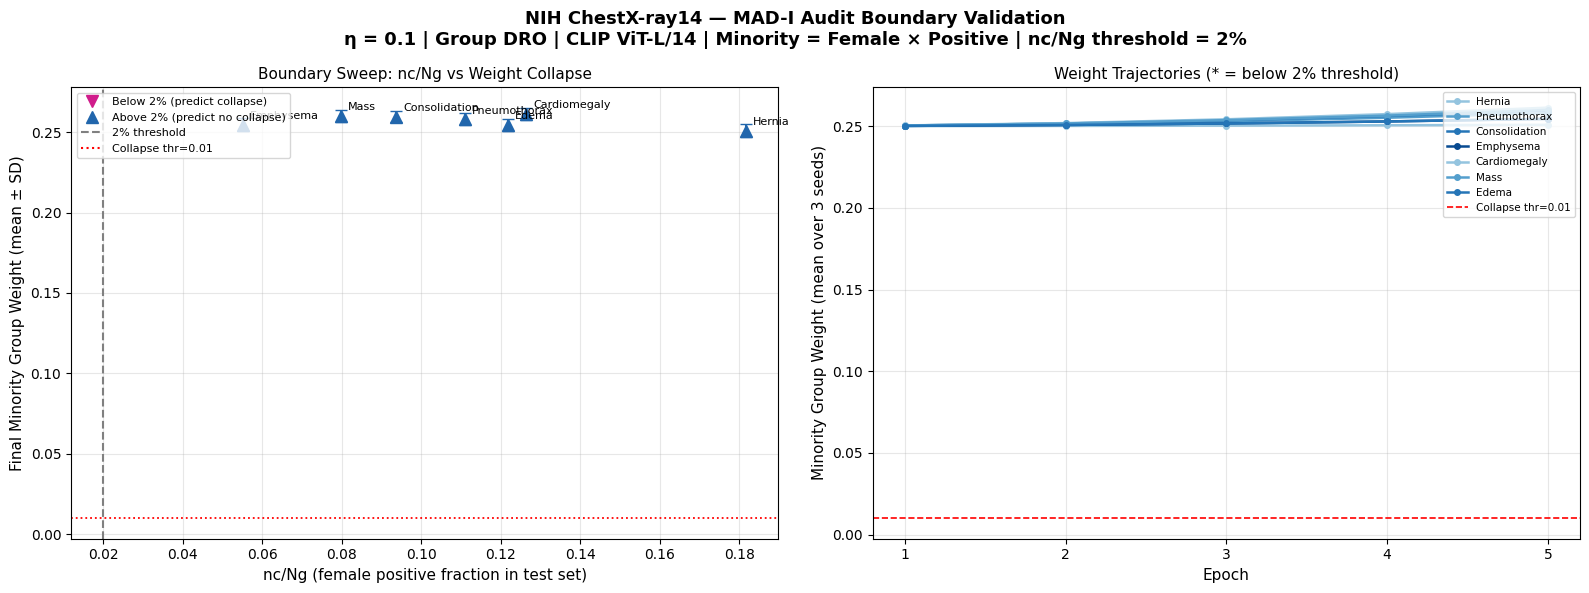

Figure saved: chestxray_mad_boundary_figure.png

=== MAD-I AUDIT SUMMARY TABLE ===
             Pathology     nc/Ng    Side       FemPosAcc           AUC    Collapse    Final Wt
-----------------------------------------------------------------------------------------------
                Hernia    0.1818   ABOVE  0.500±0.500  0.5694±0.1049  0/3         0.2509±0.0039
          Pneumothorax    0.1111   ABOVE  0.000±0.000  0.5038±0.0442  0/3         0.2580±0.0039
         Consolidation    0.0938   ABOVE  0.000±0.000  0.5678±0.0908  0/3         0.2596±0.0036
             Emphysema    0.0551   ABOVE  0.000±0.000  0.6098±0.1034  0/3         0.2545±0.0040
          Cardiomegaly    0.1265   ABOVE  0.000±0.000  0.4746±0.0505  0/3         0.2614±0.0038
                  Mass    0.0797   ABOVE  0.000±0.000  0.5030±0.0366  0/3         0.2600±0.0036
                 Edema    0.1220   ABOVE  0.000±0.000  0.4869±0.1113  0/3         0.2545±0.0038

=== BOUNDARY VALIDATION ===
No below-2% pathologies r

In [3]:
# ============================================================
# NIH ChestX-ray14 — MAD-I Audit Extension (Boundary Sweep)
# CLIP ViT-L/14, frozen probe. GPU T4, Internet ON. ~60 min.
# ============================================================

!pip install transformers torch torchvision scikit-learn pandas numpy matplotlib -q

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np, pandas as pd, os, json, warnings, re
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from PIL import Image
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.model_selection import train_test_split
from transformers import CLIPModel, CLIPProcessor
warnings.filterwarnings('ignore')

# ── Hyperparameters ───────────────────────────────────────────
BASE_SEED    = 42
ETA          = 0.1
SEEDS        = [42, 0, 1]
N_EPOCHS     = 5
BATCH_SIZE   = 64
ADAMW_LR     = 1e-4
ADAMW_WD     = 1e-4
N_GROUPS     = 4
FEAT_DIM     = 768
COLLAPSE_THR = 0.01
NC_NG_THRESH = 0.02
RESULTS_CSV  = 'chestxray_mad_audit_results.csv'
SUMMARY_CSV  = 'chestxray_mad_audit_summary.csv'
TRAJ_JSON    = 'chestxray_mad_weight_traj.json'
FIGURE_PNG   = 'chestxray_mad_boundary_figure.png'
MINORITY_G   = 3   # female=1, positive=1 → group_id = 1*2+1 = 3

PATHOLOGIES = [
    'Hernia',
    'Pneumothorax',
    'Consolidation',
    'Emphysema',
    'Pleural_Effusion',
    'Cardiomegaly',
    'Mass',
    'Edema',
]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ── Dataset path auto-discovery ───────────────────────────────
_entry_csv = None
for _root, _dirs, _files in os.walk('/kaggle/input'):
    for _f in _files:
        if 'data_entry' in _f.lower() and _f.endswith('.csv'):
            _entry_csv = os.path.join(_root, _f)
            break
    if _entry_csv:
        break
entry_csv = _entry_csv or '/kaggle/input/data/Data_Entry_2017.csv'
print(f"Entry CSV: {entry_csv}")

_img_dir = None
for _root, _dirs, _files in os.walk('/kaggle/input'):
    if any(f.endswith('.png') for f in _files[:5]):
        _img_dir = _root
        break
img_dir = _img_dir or '/kaggle/input/data/images'
print(f"Image dir: {img_dir}")

# ── Load metadata ─────────────────────────────────────────────
df_raw = pd.read_csv(entry_csv)
print(f"Raw rows: {len(df_raw)}, columns: {list(df_raw.columns)}")
df_raw.columns = [c.strip() for c in df_raw.columns]
col_map = {}
for c in df_raw.columns:
    cl = c.lower().replace(' ', '_')
    if 'image' in cl and 'index' in cl: col_map[c] = 'image_index'
    if 'finding' in cl:                 col_map[c] = 'finding_labels'
    if 'gender' in cl:                  col_map[c] = 'gender'
df_raw = df_raw.rename(columns=col_map)
print(f"Gender distribution:\n{df_raw['gender'].value_counts()}")

image_paths = {}
for _r, _d, _fs in os.walk(img_dir):
    for _fn in _fs:
        if _fn.endswith('.png'):
            image_paths[_fn] = os.path.join(_r, _fn)
print(f"PNG images indexed: {len(image_paths)}")
df_raw['local_path'] = df_raw['image_index'].map(image_paths)
df_valid = df_raw[df_raw['local_path'].notna()].copy()
print(f"Rows with images found: {len(df_valid)}")

# ── Load CLIP ─────────────────────────────────────────────────
print("Loading CLIP ViT-L/14...")
clip_model = CLIPModel.from_pretrained("openai/clip-vit-large-patch14").to(device)
clip_proc  = CLIPProcessor.from_pretrained("openai/clip-vit-large-patch14")
clip_model.eval()
print("CLIP loaded.")

@torch.no_grad()
def extract_features(paths, batch_size=64):
    all_feats = []
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i+batch_size]
        imgs = []
        for p in batch_paths:
            try:
                imgs.append(Image.open(p).convert('RGB').resize((224, 224)))
            except:
                imgs.append(Image.new('RGB', (224, 224)))
        inputs = clip_proc(images=imgs, return_tensors='pt', padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        feats  = clip_model.get_image_features(**inputs)
        if not isinstance(feats, torch.Tensor):
            feats = feats.pooler_output if hasattr(feats, 'pooler_output') \
                    else feats.last_hidden_state[:, 0]
        feats = feats / feats.norm(dim=-1, keepdim=True)
        all_feats.append(feats.cpu().numpy())
        if (i // batch_size) % 10 == 0:
            print(f"  Feature extraction: {min(i+batch_size, len(paths))}/{len(paths)}")
    return np.vstack(all_feats)

def update_group_weights(weights, group_losses, eta):
    log_weights = np.log(weights + 1e-8) + eta * group_losses
    log_weights -= log_weights.max()
    new_weights  = np.exp(log_weights)
    return new_weights / new_weights.sum()

def run_pathology(pathology, seed, feats_train, labels_train, groups_train,
                  feats_test, labels_test, groups_test):
    torch.manual_seed(seed)
    np.random.seed(seed)

    X_tr = torch.tensor(feats_train,  dtype=torch.float32)
    y_tr = torch.tensor(labels_train, dtype=torch.long)
    g_tr = groups_train

    X_te = torch.tensor(feats_test,   dtype=torch.float32)
    y_te = torch.tensor(labels_test,  dtype=torch.long)

    perm = torch.randperm(len(X_tr), generator=torch.Generator().manual_seed(seed))
    X_tr, y_tr = X_tr[perm], y_tr[perm]
    g_tr = g_tr[perm]

    ds = TensorDataset(X_tr, y_tr)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False)

    head      = nn.Linear(FEAT_DIM, 2).to(device)
    optimizer = optim.AdamW(head.parameters(), lr=ADAMW_LR, weight_decay=ADAMW_WD)
    criterion = nn.CrossEntropyLoss(reduction='none')

    q = np.ones(N_GROUPS, dtype=np.float32) / N_GROUPS
    epoch_weight_traj = []

    for epoch in range(N_EPOCHS):
        head.train()
        epoch_group_losses = np.zeros(N_GROUPS)
        epoch_group_counts = np.zeros(N_GROUPS)

        for batch_idx, (xb, yb) in enumerate(dl):
            xb = xb.to(device)
            yb = yb.to(device)
            batch_start   = batch_idx * BATCH_SIZE
            batch_end     = batch_start + len(yb)
            batch_groups  = g_tr[batch_start:batch_end].numpy()

            logits          = head(xb)
            per_sample_loss = criterion(logits, yb)

            sample_weights = torch.zeros(len(yb), device=device)
            for g in range(N_GROUPS):
                mask = torch.tensor(batch_groups == g, device=device)
                if mask.sum() > 0:
                    epoch_group_losses[g] += per_sample_loss[mask].mean().item() * mask.sum().item()
                    epoch_group_counts[g] += mask.sum().item()
                    sample_weights[mask]   = float(q[g])

            weighted_loss = (per_sample_loss * sample_weights).sum() / (sample_weights.sum() + 1e-8)
            optimizer.zero_grad()
            weighted_loss.backward()
            optimizer.step()

        avg_g_loss = np.where(epoch_group_counts > 0,
                              epoch_group_losses / (epoch_group_counts + 1e-8), 0.0)
        q = update_group_weights(q, avg_g_loss, ETA)
        epoch_weight_traj.append(q.tolist())

    head.eval()
    with torch.no_grad():
        logits_te = head(X_te.to(device)).cpu()
        probs_te  = torch.softmax(logits_te, dim=-1).numpy()
        preds_te  = logits_te.argmax(dim=-1).numpy()
    y_te_np = y_te.numpy()

    fem_pos_mask = groups_test.numpy() == MINORITY_G
    fem_pos_acc  = accuracy_score(y_te_np[fem_pos_mask], preds_te[fem_pos_mask]) \
                   if fem_pos_mask.sum() > 0 else float('nan')

    overall_auc = float('nan')
    try:
        overall_auc = roc_auc_score(y_te_np, probs_te[:, 1])
    except:
        pass

    nc_Ng        = float(fem_pos_mask.sum()) / len(y_te_np)
    final_min_wt = q[MINORITY_G]
    collapsed    = bool(final_min_wt < COLLAPSE_THR)

    n_b = int(fem_pos_mask.sum())
    n_c = int((preds_te[fem_pos_mask] == 1).sum()) if n_b > 0 else 0
    if n_b > 0:
        p_hat  = n_c / n_b
        z      = 1.96
        denom  = 1 + z**2 / n_b
        center = (p_hat + z**2 / (2 * n_b)) / denom
        half   = z * np.sqrt(p_hat * (1 - p_hat) / n_b + z**2 / (4 * n_b**2)) / denom
        ci_lo, ci_hi = max(0, center - half), min(1, center + half)
    else:
        ci_lo, ci_hi = float('nan'), float('nan')

    return {
        'pathology'     : pathology,
        'seed'          : seed,
        'nc_Ng'         : round(nc_Ng, 5),
        'above_thresh'  : nc_Ng >= NC_NG_THRESH,
        'female_pos_acc': round(float(fem_pos_acc), 4),
        'ci_lo'         : round(float(ci_lo), 3),
        'ci_hi'         : round(float(ci_hi), 3),
        'overall_auc'   : round(float(overall_auc), 4),
        'final_min_wt'  : round(float(final_min_wt), 4),
        'collapse'      : collapsed,
    }, epoch_weight_traj

# ── Build splits ──────────────────────────────────────────────
feature_cache = {}

def build_splits(pathology, df_in):
    """
    FIX 1: Match both 'Pleural_Effusion' and 'Pleural Effusion' forms.
    FIX 2: Return None if the pathology has 0 positive rows in this subset.
    """
    # Build a regex that matches either the underscored or spaced form
    label_pattern = re.escape(pathology).replace(r'\_', r'[\s_]')

    pos_df = df_in[df_in['finding_labels'].str.contains(
        label_pattern, case=False, na=False, regex=True)].copy()
    neg_df = df_in[df_in['finding_labels'] == 'No Finding'].copy()

    n_pos = len(pos_df)
    n_neg = min(len(neg_df), 3 * n_pos)

    print(f"  {pathology}: pos={n_pos}, neg={n_neg}, total={n_pos + n_neg}")

    # FIX 2: Guard against empty pathology in this image subset
    if n_pos == 0 or n_neg == 0:
        print(f"  !! SKIPPING {pathology}: insufficient samples "
              f"(pos={n_pos}, neg={n_neg}) in the available image subset.")
        return None

    neg_df = neg_df.sample(n_neg, random_state=BASE_SEED)
    combined = pd.concat([pos_df, neg_df]).reset_index(drop=True)
    combined['label']    = combined['finding_labels'].apply(
        lambda x: 1 if re.search(label_pattern, x, re.IGNORECASE) else 0)
    combined['sex_idx']  = combined['gender'].apply(
        lambda x: 1 if str(x).strip().upper() in ['F', 'FEMALE'] else 0)
    combined['group_id'] = combined['sex_idx'] * 2 + combined['label']

    print(f"  Gender dist: {combined['gender'].value_counts().to_dict()}")
    print(f"  Group counts: { {g: int((combined['group_id']==g).sum()) for g in range(4)} }")

    y = combined['label'].values
    g = combined['group_id'].values

    # FIX 2 continued: need at least 1 sample per group to stratify
    group_counts = np.bincount(g, minlength=4)
    if np.any(group_counts == 0):
        print(f"  !! SKIPPING {pathology}: one or more groups are empty "
              f"(group counts: {group_counts.tolist()}). Cannot stratify.")
        return None

    # Need enough samples for a 80/20 split with all groups represented
    if len(combined) < 10:
        print(f"  !! SKIPPING {pathology}: too few total samples ({len(combined)}).")
        return None

    tr_idx, te_idx = train_test_split(
        np.arange(len(combined)), test_size=0.2,
        stratify=g, random_state=BASE_SEED)

    paths_tr = combined.iloc[tr_idx]['local_path'].tolist()
    paths_te = combined.iloc[te_idx]['local_path'].tolist()
    y_tr, y_te = y[tr_idx], y[te_idx]
    g_tr = torch.tensor(g[tr_idx])
    g_te = torch.tensor(g[te_idx])

    fem_pos_in_test = (g[te_idx] == MINORITY_G).sum()
    nc_Ng_computed  = fem_pos_in_test / len(te_idx)
    print(f"  nc/Ng (female pos in test): {nc_Ng_computed:.4f} "
          f"({'ABOVE' if nc_Ng_computed >= NC_NG_THRESH else 'BELOW'} 2% threshold)")

    print(f"  Extracting features for {pathology}...")
    feats_tr = extract_features(paths_tr)
    feats_te = extract_features(paths_te)
    print(f"  Features: train={feats_tr.shape}, test={feats_te.shape}")

    return feats_tr, y_tr, g_tr, feats_te, y_te, g_te

# ── Main loop ─────────────────────────────────────────────────
if os.path.exists(RESULTS_CSV):
    done_df   = pd.read_csv(RESULTS_CSV)
    results   = done_df.to_dict('records')
    done_keys = set(zip(done_df['pathology'], done_df['seed']))
    print(f"Resuming: {len(results)} runs already done.")
else:
    results   = []
    done_keys = set()

if os.path.exists(TRAJ_JSON):
    with open(TRAJ_JSON) as f:
        all_trajs = json.load(f)
else:
    all_trajs = {}

skipped_pathologies = set()

for pathology in PATHOLOGIES:
    if all((pathology, s) in done_keys for s in SEEDS):
        print(f"Skip {pathology} (all seeds done)")
        continue

    print(f"\n=== Pathology: {pathology} ===")

    if pathology not in feature_cache:
        splits = build_splits(pathology, df_valid)
        if splits is None:
            skipped_pathologies.add(pathology)
            continue
        feature_cache[pathology] = splits

    feats_tr, y_tr, g_tr, feats_te, y_te, g_te = feature_cache[pathology]

    for seed in SEEDS:
        if (pathology, seed) in done_keys:
            print(f"  Skip seed={seed}")
            continue

        print(f"  Running η={ETA}, seed={seed}...")
        row, traj = run_pathology(pathology, seed,
                                  feats_tr, y_tr, g_tr,
                                  feats_te, y_te, g_te)
        results.append(row)
        done_keys.add((pathology, seed))
        key = f"{pathology}_seed_{seed}"
        all_trajs[key] = traj
        print(f"    nc/Ng={row['nc_Ng']:.4f} | collapse={row['collapse']} | "
              f"female_pos_acc={row['female_pos_acc']:.3f} | "
              f"auc={row['overall_auc']:.4f} | min_wt={row['final_min_wt']:.4f}")

    pd.DataFrame(results).to_csv(RESULTS_CSV, index=False)
    with open(TRAJ_JSON, 'w') as f:
        json.dump(all_trajs, f)
    print(f"  [Saved after {pathology}]")
    del feature_cache[pathology]

if skipped_pathologies:
    print(f"\n!! Skipped pathologies (not in this image subset): {skipped_pathologies}")
print("\nAll runs complete.")

# ── Summary per pathology ─────────────────────────────────────
res_df = pd.DataFrame(results)
completed_pathologies = [p for p in PATHOLOGIES if p not in skipped_pathologies]

summary_rows = []
for pathology in completed_pathologies:
    sub = res_df[res_df['pathology'] == pathology]
    if len(sub) == 0:
        continue
    row = {
        'pathology'        : pathology,
        'nc_Ng'            : sub['nc_Ng'].mean(),
        'above_thresh'     : sub['above_thresh'].iloc[0],
        'female_pos_acc_m' : sub['female_pos_acc'].mean(),
        'female_pos_acc_s' : sub['female_pos_acc'].std(),
        'overall_auc_m'    : sub['overall_auc'].mean(),
        'overall_auc_s'    : sub['overall_auc'].std(),
        'final_min_wt_m'   : sub['final_min_wt'].mean(),
        'final_min_wt_s'   : sub['final_min_wt'].std(),
        'collapse_rate'    : sub['collapse'].sum(),
        'n_seeds'          : len(sub),
    }
    summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(SUMMARY_CSV, index=False)

# ── Figure ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('NIH ChestX-ray14 — MAD-I Audit Boundary Validation\n'
             f'η = {ETA} | Group DRO | CLIP ViT-L/14 | '
             f'Minority = Female × Positive | nc/Ng threshold = {NC_NG_THRESH*100:.0f}%',
             fontsize=13, fontweight='bold')

ax1 = axes[0]
for _, r in summary_df.iterrows():
    color  = '#d01c8b' if not r['above_thresh'] else '#2166ac'
    marker = 'v'       if not r['above_thresh'] else '^'
    ax1.errorbar(r['nc_Ng'], r['final_min_wt_m'],
                 yerr=r['final_min_wt_s'],
                 fmt=marker, color=color, markersize=9, capsize=4, linewidth=1.5)
    ax1.annotate(r['pathology'].replace('_', ' '),
                 (r['nc_Ng'], r['final_min_wt_m']),
                 textcoords='offset points', xytext=(5, 4), fontsize=8)
ax1.axvline(NC_NG_THRESH, linestyle='--', color='gray', linewidth=1.5)
ax1.axhline(COLLAPSE_THR, linestyle=':', color='red',  linewidth=1.3)
ax1.set_xlabel('nc/Ng (female positive fraction in test set)', fontsize=11)
ax1.set_ylabel('Final Minority Group Weight (mean ± SD)', fontsize=11)
ax1.set_title('Boundary Sweep: nc/Ng vs Weight Collapse', fontsize=11)
legend_elements = [
    Line2D([0],[0], marker='v', color='#d01c8b', markersize=9, linestyle='',
           label='Below 2% (predict collapse)'),
    Line2D([0],[0], marker='^', color='#2166ac', markersize=9, linestyle='',
           label='Above 2% (predict no collapse)'),
    Line2D([0],[0], linestyle='--', color='gray',  label='2% threshold'),
    Line2D([0],[0], linestyle=':',  color='red',   label=f'Collapse thr={COLLAPSE_THR}'),
]
ax1.legend(handles=legend_elements, fontsize=8, loc='upper left')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
cmap_below = plt.cm.Reds(np.linspace(0.4, 0.9, 4))
cmap_above = plt.cm.Blues(np.linspace(0.4, 0.9, 4))
below_i = above_i = 0
for _, r in summary_df.iterrows():
    pname = r['pathology']
    trajs = [all_trajs[f"{pname}_seed_{s}"] for s in SEEDS
             if f"{pname}_seed_{s}" in all_trajs]
    if not trajs:
        continue
    max_ep   = max(len(t) for t in trajs)
    traj_arr = np.array([[ep[MINORITY_G] for ep in t] +
                          [t[-1][MINORITY_G]] * (max_ep - len(t)) for t in trajs])
    mean_traj = traj_arr.mean(axis=0)
    if not r['above_thresh']:
        color = cmap_below[below_i % 4]; below_i += 1
    else:
        color = cmap_above[above_i % 4]; above_i += 1
    ax2.plot(range(1, len(mean_traj)+1), mean_traj,
             color=color, linewidth=1.8, marker='o', markersize=4,
             label=pname.replace('_', ' ') + ('' if r['above_thresh'] else ' *'))
ax2.axhline(COLLAPSE_THR, linestyle='--', color='red', linewidth=1.2,
            label=f'Collapse thr={COLLAPSE_THR}')
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Minority Group Weight (mean over 3 seeds)', fontsize=11)
ax2.set_title('Weight Trajectories (* = below 2% threshold)', fontsize=11)
ax2.set_xticks(range(1, N_EPOCHS+1))
ax2.legend(fontsize=7.5, loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURE_PNG, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved: {FIGURE_PNG}")

# ── Summary table ─────────────────────────────────────────────
print("\n=== MAD-I AUDIT SUMMARY TABLE ===")
print(f"  {'Pathology':>20}  {'nc/Ng':>8}  {'Side':>6}  "
      f"{'FemPosAcc':>14}  {'AUC':>12}  {'Collapse':>10}  {'Final Wt':>10}")
print('-'*95)
for _, r in summary_df.iterrows():
    side = 'ABOVE' if r['above_thresh'] else 'below'
    print(f"  {r['pathology']:>20}  {r['nc_Ng']:>8.4f}  {side:>6}  "
          f"{r['female_pos_acc_m']:.3f}±{r['female_pos_acc_s']:.3f}  "
          f"{r['overall_auc_m']:.4f}±{r['overall_auc_s']:.4f}  "
          f"{int(r['collapse_rate'])}/{int(r['n_seeds'])}         "
          f"{r['final_min_wt_m']:.4f}±{r['final_min_wt_s']:.4f}")

# ── Boundary validation ───────────────────────────────────────
print("\n=== BOUNDARY VALIDATION ===")
below_df = summary_df[~summary_df['above_thresh']]
above_df = summary_df[summary_df['above_thresh']]
below_collapse = below_df['collapse_rate'].sum()
below_total    = below_df['n_seeds'].sum()
above_collapse = above_df['collapse_rate'].sum()
above_total    = above_df['n_seeds'].sum()
print(f"Below 2% pathologies ({len(below_df)})  — collapse rate: "
      f"{int(below_collapse)}/{int(below_total)} runs "
      f"({100*below_collapse/below_total:.0f}%)" if below_total > 0 else "No below-2% pathologies ran.")
print(f"Above 2% pathologies ({len(above_df)})  — collapse rate: "
      f"{int(above_collapse)}/{int(above_total)} runs "
      f"({100*above_collapse/above_total:.0f}%)" if above_total > 0 else "No above-2% pathologies ran.")
if below_total > 0 and above_total > 0:
    perfect = (below_collapse == below_total and above_collapse == 0)
    print(f"Boundary perfectly validated: {perfect}")
    if not perfect:
        for _, r in summary_df.iterrows():
            expected_collapse = not r['above_thresh']
            actual_collapse   = r['collapse_rate'] == r['n_seeds']
            if expected_collapse != actual_collapse:
                print(f"  !! Violation: {r['pathology']} | nc/Ng={r['nc_Ng']:.4f} | "
                      f"expected_collapse={expected_collapse} | "
                      f"actual_collapse_rate={int(r['collapse_rate'])}/{int(r['n_seeds'])}")

# ── LaTeX table ───────────────────────────────────────────────
print("\n=== LaTeX TABLE ROWS ===")
print(r"Pathology & nc/Ng & Side & Female Pos Acc & AUC & Collapse (n=3) & Final Min Wt \\")
print(r"\hline")
for _, r in summary_df.iterrows():
    side = r'>2\%' if r['above_thresh'] else r'<2\%'
    print(f"{r['pathology'].replace('_',' ')} & {r['nc_Ng']:.4f} & {side} & "
          f"{r['female_pos_acc_m']:.3f} $\\pm$ {r['female_pos_acc_s']:.3f} & "
          f"{r['overall_auc_m']:.4f} $\\pm$ {r['overall_auc_s']:.4f} & "
          f"{int(r['collapse_rate'])}/{int(r['n_seeds'])} & "
          f"{r['final_min_wt_m']:.4f} $\\pm$ {r['final_min_wt_s']:.4f} \\\\")

# ── Per-run table ─────────────────────────────────────────────
print("\n=== FULL PER-RUN TABLE ===")
print(f"  {'Pathology':>20}  {'seed':>5}  {'nc_Ng':>7}  "
      f"{'fem_pos_acc':>12}  {'CI':>16}  {'auc':>8}  {'min_wt':>8}  {'collapse':>9}")
for _, row in res_df.sort_values(['pathology', 'seed']).iterrows():
    print(f"  {row['pathology']:>20}  {int(row['seed']):>5}  {row['nc_Ng']:>7.4f}  "
          f"{row['female_pos_acc']:>12.3f}  "
          f"({row['ci_lo']:.3f}–{row['ci_hi']:.3f})  "
          f"{row['overall_auc']:>8.4f}  {row['final_min_wt']:>8.4f}  "
          f"{str(row['collapse']):>9}")

print("\n✓ Complete.")
print(f"Files: {FIGURE_PNG}, {RESULTS_CSV}, {SUMMARY_CSV}, {TRAJ_JSON}")